## **Unsupervised Model II – Autoencoder**

An autoencoder learns to compress and reconstruct "normal" user behaviour. Users whose features reconstruct poorly (high reconstruction error) are flagged as anomalous.

**Two training modes compared:**
- **Unsupervised** — train on all users (including contaminated anomalies). The model learns the dominant normal pattern; anomalies are noise it can't reconstruct well.
- **Semi-supervised** — train on normal users only, for training and validation sets. Only the calibration set (to align with codabench's threshold = 0.5) contains both normal and anomalous users.

**Architecture:** shallow bottleneck (24→8→3→8→24) to force compression on ~1K users without overfitting.

#### **Imports and Helper Functions**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

from feature_pipeline import (
    load_npz, load_data, exclude_test_users, compute_item_stats,
    build_features, get_feature_columns, get_test_labels,
)

RANDOM_SEED = 42
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def split_datasets(X, y, train_users, val_users, cal_users):
    # Split interactions dataframe into train, val, cal sets based on user
    X_train = X[X["user"].isin(train_users["user"])]
    X_val = X[X["user"].isin(val_users["user"])]
    X_cal = X[X["user"].isin(cal_users["user"])]

    # Split label dataframe into train, val, cal sets based on user
    y_train = y[y["user"].isin(train_users["user"])]
    y_val = y[y["user"].isin(val_users["user"])]
    y_cal = y[y["user"].isin(cal_users["user"])]

    print("\nTrain label counts:")
    print(y_train["label"].value_counts())

    print("\nVal label counts:")
    print(y_val["label"].value_counts())

    print("\nCalibration label counts:")
    print(y_cal["label"].value_counts())

    return X_train, y_train, X_val, y_val, X_cal, y_cal


def codabench_metrics(
    test_labels: np.ndarray,
    scores: np.ndarray,
    model_name: str,
    verbose=False,
) -> dict:
    """Compute metrics at the fixed Codabench threshold of 0.5.

    Use this on calibrated scores to see exactly what Codabench will report.
    """
    preds = (scores >= 0.5).astype(int)
    metrics = {
        "model": model_name,
        "AUC": roc_auc_score(test_labels, scores),
        "Precision": precision_score(test_labels, preds, zero_division=0),
        "Recall": recall_score(test_labels, preds, zero_division=0),
        "F1": f1_score(test_labels, preds, zero_division=0),
        "threshold": 0.5,
    }

    if verbose: 
        print(f"{model_name} (Codabench t=0.5)")
        print(f"# AUC:       {metrics['AUC']:.4f}")
        print(f"# Precision: {metrics['Precision']:.4f}")
        print(f"# Recall:    {metrics['Recall']:.4f}")
        print(f"# F1 Score:  {metrics['F1']:.4f}")

    return metrics


def save_submission(scores, filename):
    """Save anomaly scores as a Codabench submission file."""
    np.savez(filename, predictions=scores)
    print(f"Saved to {filename}")



#### **Model definition**

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=(12, 6), dropout=0.2):
        super().__init__()

        # Encoder
        encoder_layers = []
        prev = input_dim
        for h in hidden_dims:
            encoder_layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder (mirrors encoder)
        decoder_layers = []
        for h in reversed(hidden_dims[:-1]):
            decoder_layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        decoder_layers.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        """Per-sample MSE reconstruction error (used as anomaly score)."""
        with torch.no_grad():
            x_hat = self.forward(x)
            return ((x - x_hat) ** 2).mean(dim=1).numpy()

#### **Training Function**

In [4]:
def train_autoencoder(
    X_train,
    X_val,
    hidden_dims=(12, 6),
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=200,
    batch_size=64,
    patience=20,
):
    """Train autoencoder in unsupervised or semi-supervised mode.

    Args:
        # re-write args properly
    Returns: (model, scaler, train_losses, val_losses)
    """
    print(f"\nTRAINING AUTOENCODER (dims={hidden_dims}, dropout={dropout}, lr={lr})...")

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    X_train_t = torch.FloatTensor(X_train_scaled)
    X_val_t = torch.FloatTensor(X_val_scaled)

    train_loader = DataLoader(TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)

    # Model
    input_dim = X_train.shape[1]
    model = Autoencoder(input_dim, hidden_dims=hidden_dims, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    # Training loop with early stopping
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for (batch,) in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        train_losses.append(epoch_loss / len(X_train_t))

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), X_val_t).item()
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.6f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    print(f"  Final train loss: {train_losses[-1]:.6f}, best val loss: {best_val_loss:.6f}")
    return model, scaler, train_losses, val_losses

#### **Evaluation Functions**

In [5]:
def get_anomaly_scores(model, scaler, X):
    """Compute per-sample reconstruction error as anomaly scores."""
    X_t = torch.FloatTensor(scaler.transform(X))
    return model.reconstruction_error(X_t)


def per_feature_mse(model, scaler, X):
    """Return (n_samples, n_features) matrix of squared reconstruction errors."""
    X_scaled = scaler.transform(X)
    with torch.no_grad():
        X_hat = model(torch.FloatTensor(X_scaled)).numpy()
    return (X_scaled - X_hat) ** 2

#### **Plotting Functions**

In [6]:
def plot_training_curves(train_losses, val_losses, title="Training curves", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(train_losses, label="Train")
    ax.plot(val_losses, label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()


def plot_recon_error(scores, labels, title, ax=None):
    """Histogram of reconstruction errors split by class."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(scores[labels == 0], bins=40, alpha=0.6, label="Normal", density=True)
    anomaly_mask = labels == 1
    if anomaly_mask.sum() > 0:
        ax.hist(scores[labels == 1], bins=40, alpha=0.6, label="Anomalous", density=True)
    ax.set_xlabel("Reconstruction Error")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()


def plot_per_feature_mse(mse_norm, mse_anom, feature_cols, ax=None, top_n=8):
    """Bar chart of features with largest error gap between anomalous and normal.

    Args:
        mse_norm: mean per-feature MSE for normal users (1D array).
        mse_anom: mean per-feature MSE for anomalous users (1D array).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    top_idx = np.argsort(mse_anom - mse_norm)[-top_n:]
    top_feats = [feature_cols[i] for i in top_idx]
    y_pos = np.arange(top_n)

    ax.barh(y_pos - 0.15, mse_norm[top_idx], height=0.3, label="Normal", alpha=0.7)
    ax.barh(y_pos + 0.15, mse_anom[top_idx], height=0.3, label="Anomalous", alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats, fontsize=8)
    ax.set_xlabel("MSE")
    ax.set_title("Per-Feature Error ({top_n})")
    ax.legend(fontsize=8)


def plot_calibration_diagnostics(y_true, raw_scores, calibrated_probs, title="Calibrated Probabilities", n_bins=10):
    """Side-by-side: raw scores, calibrated probabilities, and reliability diagram."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(raw_scores[y_true == 0], bins=30, alpha=0.6, density=True, label="Normal")
    axes[0].hist(raw_scores[y_true == 1], bins=30, alpha=0.6, density=True, label="Anomalous")
    axes[0].set_title("Raw reconstruction scores")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    axes[1].hist(calibrated_probs[y_true == 0], bins=30, alpha=0.6, density=True, label="Normal")
    axes[1].hist(calibrated_probs[y_true == 1], bins=30, alpha=0.6, density=True, label="Anomalous")
    axes[1].axvline(0.5, linestyle="--")
    axes[1].set_title(title)
    axes[1].set_xlabel("Predicted anomaly probability")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    frac_pos, mean_pred = calibration_curve(y_true, calibrated_probs, n_bins=n_bins, strategy="quantile")
    axes[2].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    axes[2].plot(mean_pred, frac_pos, marker="o", label="Model")
    axes[2].set_title(f"Calibration curve\nBrier={brier_score_loss(y_true, calibrated_probs):.4f}")
    axes[2].set_xlabel("Mean predicted probability")
    axes[2].set_ylabel("Observed anomaly frequency")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


## **Phase 1: First Batch**

In [7]:
results_p1 = []

#### **Experiment 1: Unsupervised vs Semi-Supervised**

In [8]:
X, y = load_npz("data/training_batch_with_labels.npz")
summary_df = (
    y.groupby("label")["user"]
    .nunique()
    .rename(index={0: "Normal", 1: "Anomalous"})
    .reset_index(name="User Count")
)
print(summary_df)
print(f"Unique items: {X["item"].nunique()}")

TOTAL_ITEMS = 1000 # Item universe = 1000

       label  User Count
0     Normal        1000
1  Anomalous         100
Unique items: 993


##### **Unsupervised Model & Data Split**


In [9]:
# UNSUPERVISED: TRAIN, VALIDATION, CALIBRATION - BOTH NORMAL AND ANOMALOUS

# (Stratified) Split users into train, validation, calibration sets (70/10/20)
X, y = load_npz("data/training_batch_with_labels.npz")
y = y[["user", "label"]].drop_duplicates()
train_users, other_users = train_test_split(y, test_size=0.3, random_state=RANDOM_SEED, stratify=y["label"])
val_users, cal_users = train_test_split(other_users, test_size=2/3, random_state=RANDOM_SEED, stratify=other_users["label"])

X_train_unsup, y_train_unsup, X_val_unsup, y_val_unsup, X_cal_unsup, y_cal_unsup = split_datasets(X, y, train_users, val_users, cal_users)

# Build features for train, val, test sets (global stats based on train data only)
item_stats = compute_item_stats(X_train_unsup)

# Training data
user_df = build_features(X_train_unsup, item_stats).merge(y_train_unsup, on="user")
feature_cols = get_feature_columns(user_df)
X_train_unsup = user_df[feature_cols].values
y_train_unsup = user_df["label"].values

# Validation data
val_df = build_features(X_val_unsup, item_stats).merge(y_val_unsup, on="user")
X_val_unsup = val_df[feature_cols].values
y_val = val_df["label"].values

# Calibration data
cal_df = build_features(X_cal_unsup, item_stats).merge(y_cal_unsup, on="user")
X_cal_unsup = cal_df[feature_cols].values
y_cal_unsup = cal_df["label"].values

# Test data
X_test, y_test = load_npz("data/first_batch_with_labels.npz")
test_df = build_features(X_test, item_stats)
X_test = test_df[feature_cols].values
y_test = test_df[["user"]].merge(y_test, on="user")["label"].values



Train label counts:
label
0    700
1     70
Name: count, dtype: int64

Val label counts:
label
0    100
1     10
Name: count, dtype: int64

Calibration label counts:
label
0    200
1     20
Name: count, dtype: int64



TRAINING AUTOENCODER (dims=(12, 6), dropout=0.2, lr=0.001)...
  Early stopping at epoch 171 (best val loss: 0.382752)
  Final train loss: 0.525881, best val loss: 0.382752


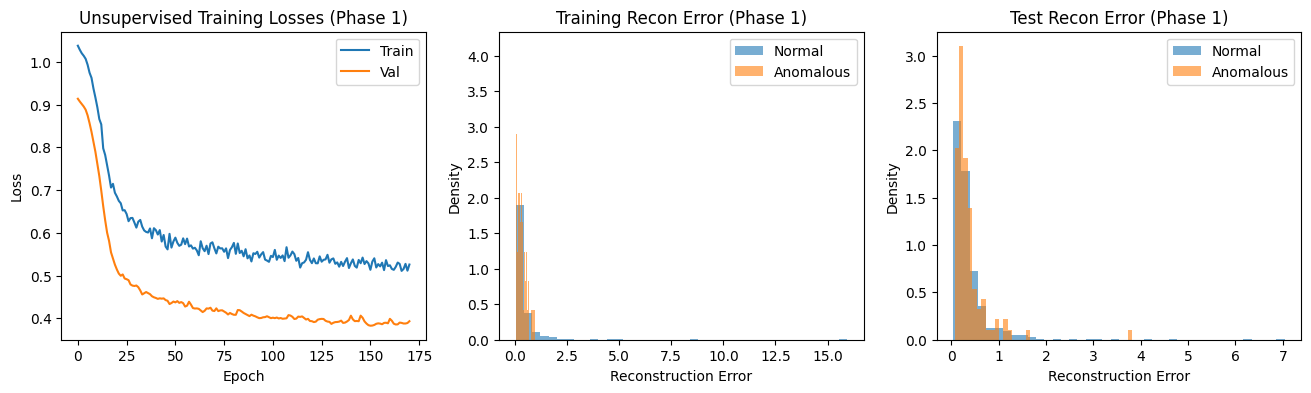

In [10]:
# Train the unsupervised model
model_unsup_p1, scaler_unsup, tl_unsup, vl_unsup = train_autoencoder(
    X_train_unsup, X_val_unsup,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot training loss graphs
plot_training_curves(tl_unsup, vl_unsup, "Unsupervised Training Losses (Phase 1)", axes[0])
# Plot training reconstruction error
scores_unsup_train = get_anomaly_scores(model_unsup_p1, scaler_unsup, X_train_unsup)
plot_recon_error(scores_unsup_train, y_train_unsup, "Training Recon Error (Phase 1)", axes[1])


# Evaluate the model on test data
scores_unsup_test = get_anomaly_scores(model_unsup_p1, scaler_unsup, X_test)
plot_recon_error(scores_unsup_test, y_test, "Test Recon Error (Phase 1)", axes[2])


##### **Semi-Supervised Model & Data Split**


In [11]:
# SEMI-SUPERVISED: TRAIN, VALIDATION - NORMAL USERS ONLY, CALIBRATION - BOTH NORMAL AND ANOMALOUS

# Split users by normal/anomalous
X, y = load_npz("data/training_batch_with_labels.npz")
y = y[["user", "label"]].drop_duplicates()
normal_users = y[y["label"] == 0].copy()
anomalous_users = y[y["label"] == 1].copy()
print(f"{len(normal_users)} normal users")
print(f"{len(anomalous_users)} anomalous users")

# Split NORMAL users into train, validation, calibration sets (80/10/10)
train_users, other_users = train_test_split(normal_users, test_size=0.2, random_state=RANDOM_SEED, shuffle=True)
val_users, cal_norm_users = train_test_split(other_users, test_size=0.5, random_state=RANDOM_SEED, shuffle=True)

# Add anomalous users to calibration set
cal_users = pd.concat([cal_norm_users, anomalous_users], ignore_index=True)
cal_users = cal_users.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

X_train, y_train, X_val, y_val, X_cal, y_cal = split_datasets(X, y, train_users, val_users, cal_users)

# Build features for train, val, test sets (global stats based on train data only)
item_stats = compute_item_stats(X_train)

# Training data
user_df = build_features(X_train, item_stats, TOTAL_ITEMS).merge(y_train, on="user")
feature_cols = get_feature_columns(user_df)
X_train = user_df[feature_cols].values
y_train = user_df["label"].values

# Validation data
val_df = build_features(X_val, item_stats, TOTAL_ITEMS).merge(y_val, on="user")
X_val = val_df[feature_cols].values
y_val = val_df["label"].values

# Calibration data
cal_df = build_features(X_cal, item_stats, TOTAL_ITEMS).merge(y_cal, on="user")
X_cal = cal_df[feature_cols].values
y_cal = cal_df["label"].values

# Test data
X_test, y_test = load_npz("data/first_batch_with_labels.npz")
test_df = build_features(X_test, item_stats, TOTAL_ITEMS)
X_test = test_df[feature_cols].values
y_test = test_df[["user"]].merge(y_test, on="user")["label"].values

1000 normal users
100 anomalous users

Train label counts:
label
0    800
Name: count, dtype: int64

Val label counts:
label
0    100
Name: count, dtype: int64

Calibration label counts:
label
1    100
0    100
Name: count, dtype: int64



TRAINING AUTOENCODER (dims=(12, 6), dropout=0.2, lr=0.001)...
  Early stopping at epoch 116 (best val loss: 0.497987)
  Final train loss: 0.508779, best val loss: 0.497987


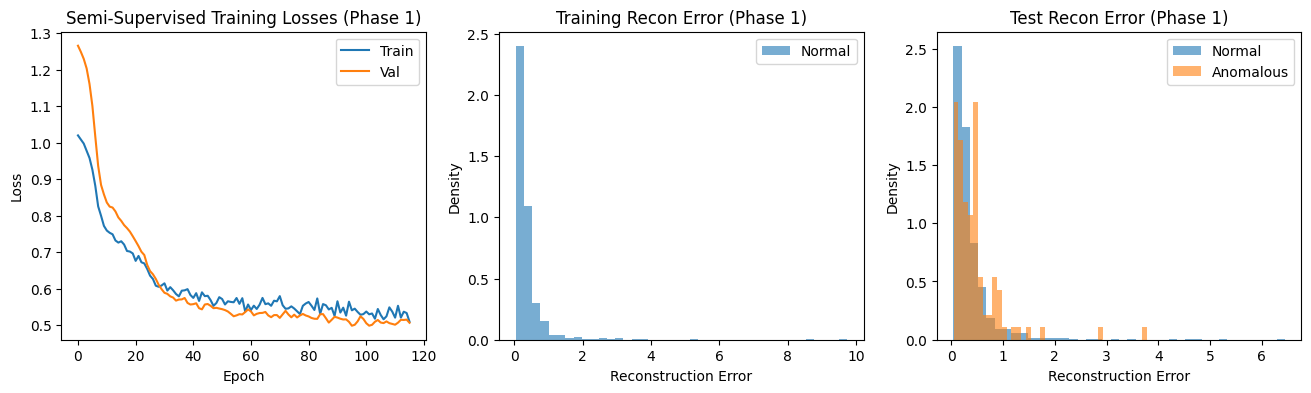

In [12]:
# Train the semi-supervised model
model_semi_p1, scaler_semi, tl_semi, vl_semi = train_autoencoder(
    X_train, X_val, 
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot training loss graphs
plot_training_curves(tl_semi, vl_semi, "Semi-Supervised Training Losses (Phase 1)", axes[0])
# Plot training reconstruction error
scores_semi_train = get_anomaly_scores(model_semi_p1, scaler_semi, X_train)
plot_recon_error(scores_semi_train, y_train, "Training Recon Error (Phase 1)", axes[1])


# Evaluate the model on test data
scores_semi_test = get_anomaly_scores(model_semi_p1, scaler_semi, X_test)
plot_recon_error(scores_semi_test, y_test, "Test Recon Error (Phase 1)", axes[2])

#### **Experiment 1a: Model and Training Tweaks**

In [13]:
AE_SMALL = dict(
    hidden_dims=(8, 3),
    dropout=0.2,
    lr=5e-4,
    weight_decay=1e-3,
    epochs=200,
    batch_size=64,
    patience=30,
)


TRAINING AUTOENCODER (dims=(8, 3), dropout=0.2, lr=0.0005)...
  Final train loss: 0.654264, best val loss: 0.490933


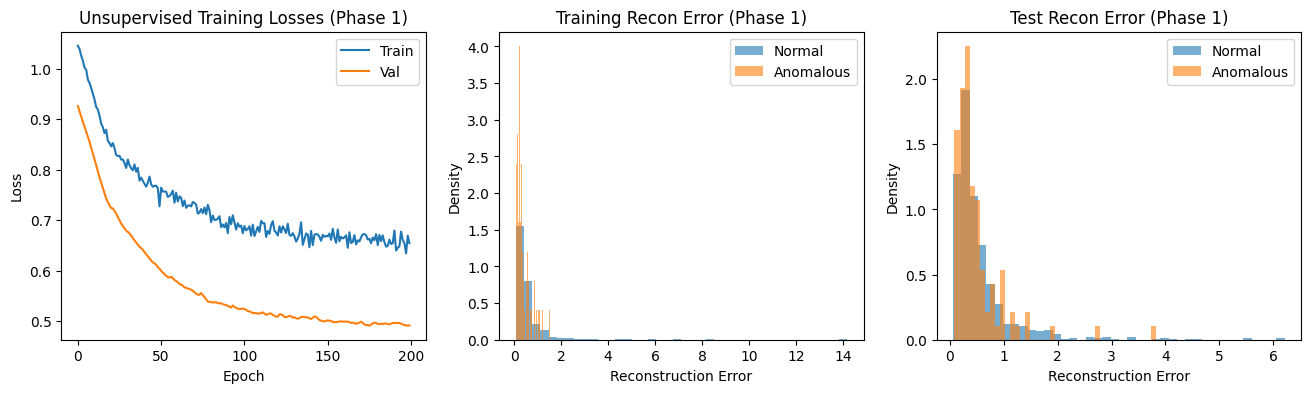

In [14]:
# Train the unsupervised model
model_unsup_p1, scaler_unsup, tl_unsup, vl_unsup = train_autoencoder(
    X_train_unsup, X_val_unsup,
    **AE_SMALL
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot training loss graphs
plot_training_curves(tl_unsup, vl_unsup, "Unsupervised Training Losses (Phase 1)", axes[0])
# Plot training reconstruction error
scores_unsup_train = get_anomaly_scores(model_unsup_p1, scaler_unsup, X_train_unsup)
plot_recon_error(scores_unsup_train, y_train_unsup, "Training Recon Error (Phase 1)", axes[1])


# Evaluate the model on test data
scores_unsup_test = get_anomaly_scores(model_unsup_p1, scaler_unsup, X_test)
plot_recon_error(scores_unsup_test, y_test, "Test Recon Error (Phase 1)", axes[2])


TRAINING AUTOENCODER (dims=(8, 3), dropout=0.2, lr=0.0005)...
  Final train loss: 0.650842, best val loss: 0.654196


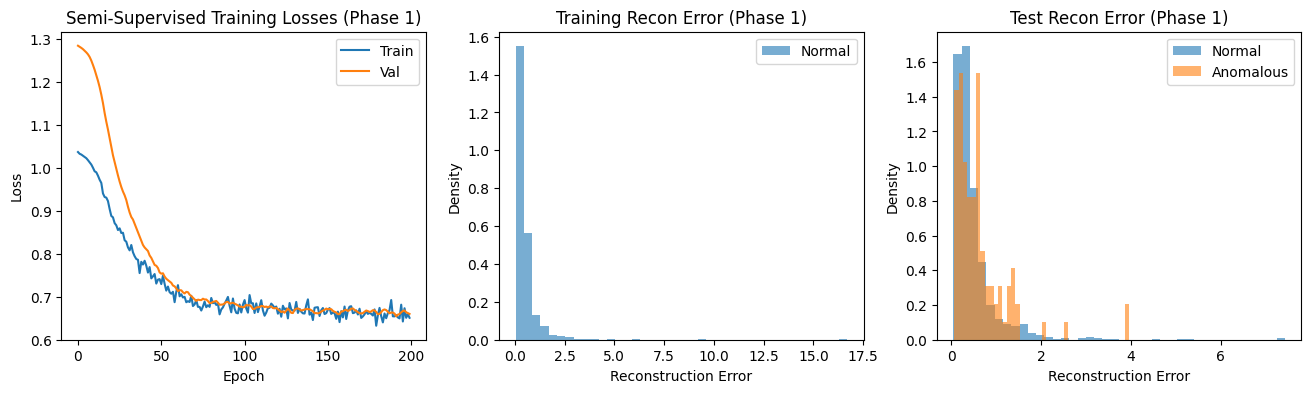

In [15]:
# Train the semi-supervised model
model_semi_p1, scaler_semi, tl_semi, vl_semi = train_autoencoder(
    X_train, X_val, 
    **AE_SMALL
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot training loss graphs
plot_training_curves(tl_semi, vl_semi, "Semi-Supervised Training Losses (Phase 1)", axes[0])
# Plot training reconstruction error
scores_semi_train = get_anomaly_scores(model_semi_p1, scaler_semi, X_train)
plot_recon_error(scores_semi_train, y_train, "Training Recon Error (Phase 1)", axes[1])


# Evaluate the model on test data
scores_semi_test = get_anomaly_scores(model_semi_p1, scaler_semi, X_test)
plot_recon_error(scores_semi_test, y_test, "Test Recon Error (Phase 1)", axes[2])

##### **Unupervised vs Semi-Supervised Conclusion**

(add insights here)

#### **Experiment 2: Calibration Modes**

In experiment 1, we use the raw MSE reconstruction loss as the anomaly score. 

Now, we explore different methods of calibrating the scores obtained above, in order to better match the 0.5 threshold set on Codabench. As a baseline, we have a threshold mapping (Monotonic Threshold Mapping), which normalises scores using MinMaxScaling at the optimal threshold to obtain the F1, Precision, Recall and AUC scores. 

1. Platt Calibration

2. Isotonic Calibration

3. Monotonic Threshold Mapping (Baseline)

In [16]:
# Calibration Helper Functions

def platt_calibrator(labels_fit, scores_fit, scores_transform):
    lr = LogisticRegression()
    lr.fit(scores_fit.reshape(-1, 1), labels_fit)
    test_probs = lr.predict_proba(scores_transform.reshape(-1, 1))[:, 1]
    return test_probs


def iso_calibrator(labels_fit, scores_fit, scores_transform):
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(scores_fit, labels_fit)
    test_probs = iso.transform(scores_transform)
    return test_probs


def mono_mapping(labels_fit, scores_fit, scores_transform):
        scores_norm = MinMaxScaler().fit_transform(scores_fit.reshape(-1, 1)).ravel()
        best_f1, t_opt = 0, 0.5
        for t in np.linspace(0.01, 0.99, 500):
            f = f1_score(labels_fit, (scores_norm >= t).astype(int), zero_division=0)
            if f > best_f1:
                best_f1, t_opt = f, t

        # Apply same normalisation to test scores using train min/max
        t_min, t_max = scores_fit.min(), scores_fit.max()
        test_norm = (scores_transform - t_min) / (t_max - t_min + 1e-9)
        test_norm = np.clip(test_norm, 0, 1)

        calibrated = np.where(
            test_norm <= t_opt,
            0.5 * test_norm / (t_opt + 1e-9),
            0.5 + 0.5 * (test_norm - t_opt) / (1.0 - t_opt + 1e-9),
        )
        calibrated = np.clip(calibrated, 0, 1)
        return calibrated


# Reusable function for both supervised/semi-supervised models to compare all 3 calibration modes
def calibration_experiment(y_cal, cal_scores, test_scores, model_type):
    print("Platt calibration, full")
    test_probs = platt_calibrator(y_cal, cal_scores, test_scores)
    res = codabench_metrics(y_test, test_probs, f"AE {model_type}, Platt, full")
    results_p1.append(res)
    plot_calibration_diagnostics(y_test, test_scores, test_probs, "Platt calibration, full")


    print("Isotonic calibration, full")
    test_probs = iso_calibrator(y_cal, cal_scores, test_scores)
    res = codabench_metrics(y_test, test_probs, f"AE {model_type}, Iso, full")
    results_p1.append(res)
    plot_calibration_diagnostics(y_test, test_scores, test_probs, "Isotonic calibration, full")


    print("Threshold Mapping (base), full")
    test_probs = mono_mapping(y_cal, cal_scores, test_scores)
    res = codabench_metrics(y_test, test_probs, f"AE {model_type}, Mapping (base), full")
    results_p1.append(res)
    plot_calibration_diagnostics(y_test, test_scores, test_probs, "Threshold Mapping, full")

##### **Calibration on Unsupervised Model Scores**

Platt calibration, full


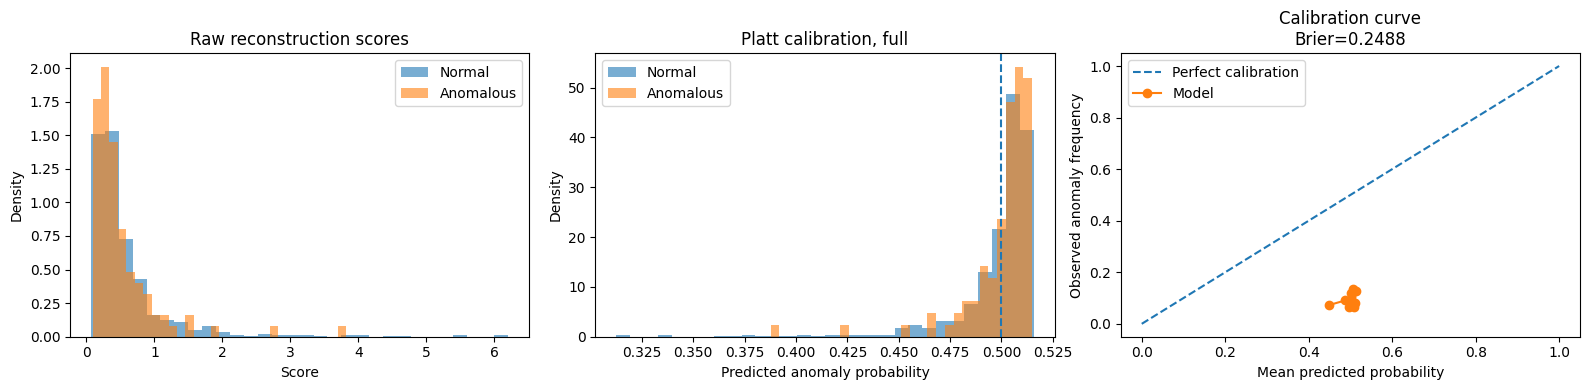

Isotonic calibration, full


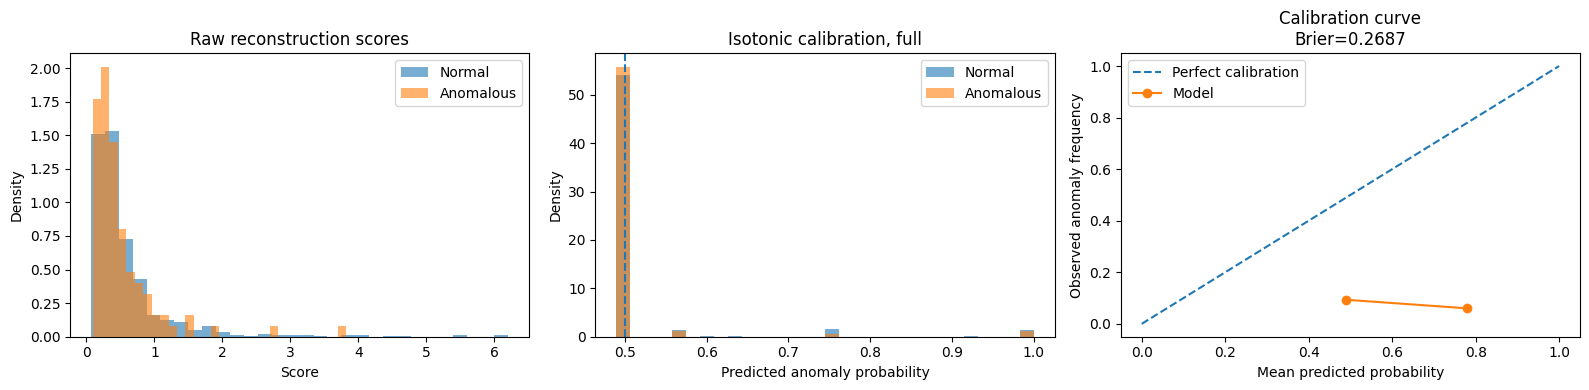

Threshold Mapping (base), full


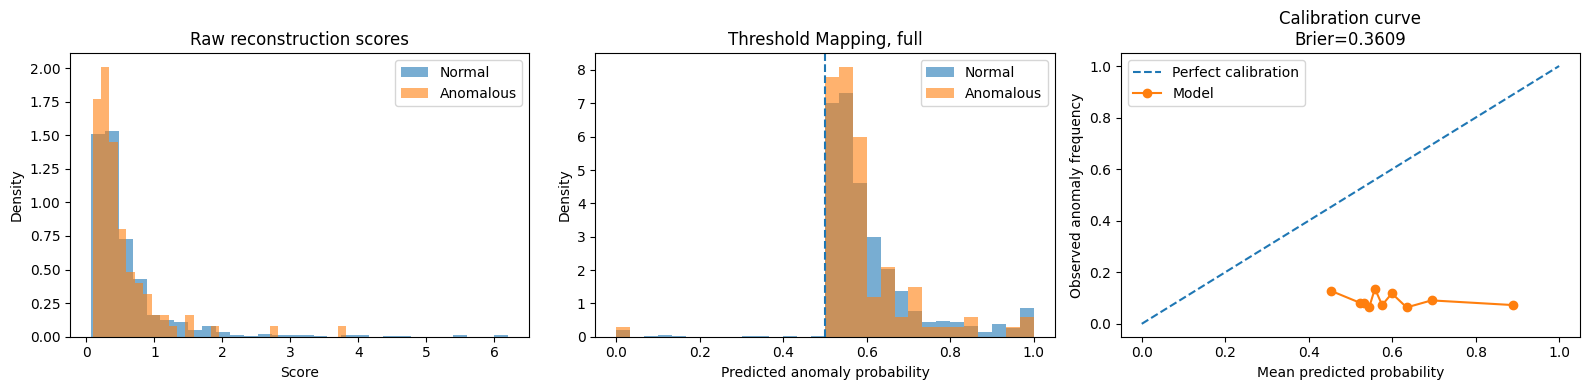

In [17]:
scores_cal_full = get_anomaly_scores(model_unsup_p1, scaler_unsup, X_cal)
scores_test_full = get_anomaly_scores(model_unsup_p1, scaler_unsup, X_test)

calibration_experiment(y_cal, scores_cal_full, scores_test_full, "Unsupervised")

##### **Calibration on Semi-Supervised Model Scores**

Platt calibration, full


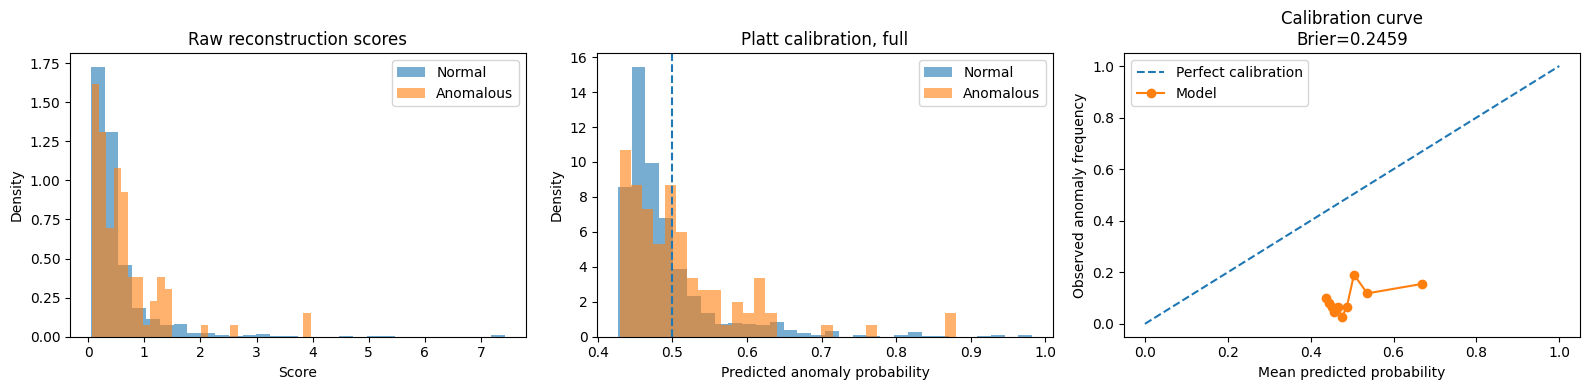

Isotonic calibration, full


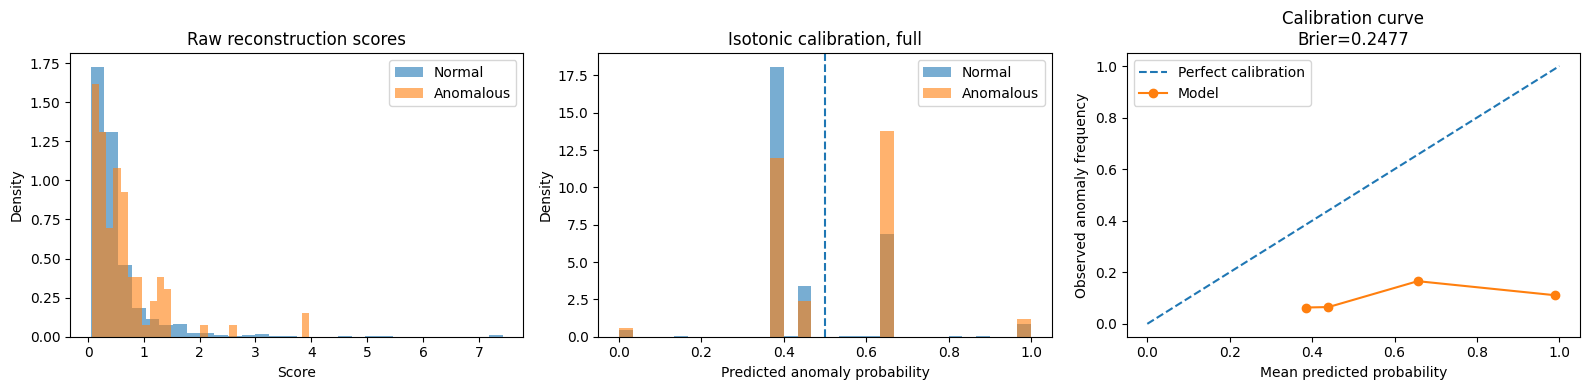

Threshold Mapping (base), full


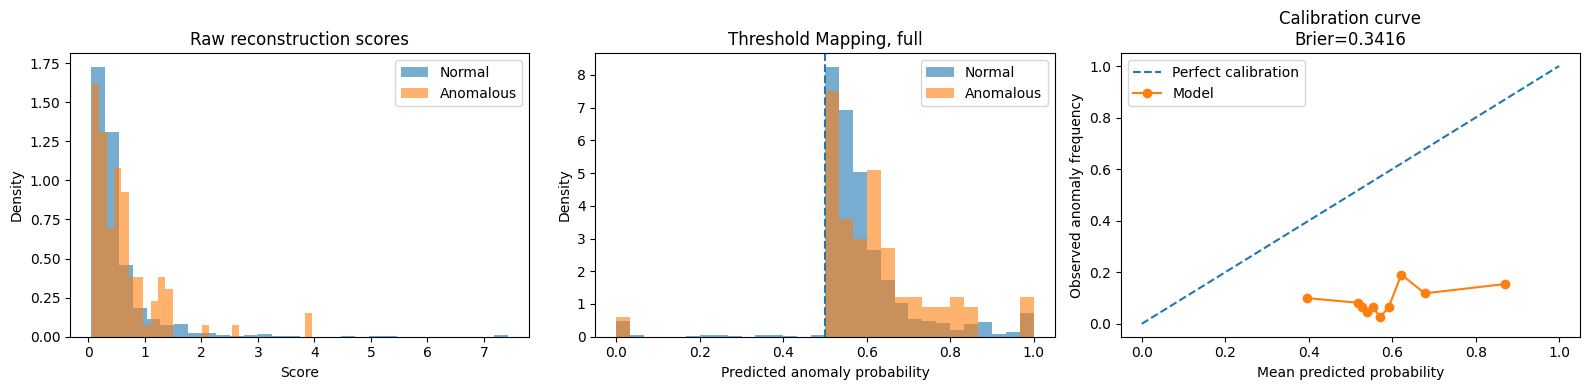

In [18]:
scores_cal_full = get_anomaly_scores(model_semi_p1, scaler_semi, X_cal)
scores_test_full = get_anomaly_scores(model_semi_p1, scaler_semi, X_test)

calibration_experiment(y_cal, scores_cal_full, scores_test_full, "Semi-Supervised")

In [19]:
results_df = pd.DataFrame(results_p1)
results_df = results_df.sort_values(by="F1", ascending=False)

results_df

,model,AUC,Precision,Recall,F1,threshold
4,"AE Semi-Supervised, Iso, full",0.613195,0.159236,0.50,0.241546,0.5
3,"AE Semi-Supervised, Platt, full",0.585740,0.154110,0.45,0.229592,0.5
0,"AE Unsupervised, Platt, full",0.531510,0.101788,0.74,0.178960,0.5
5,"AE Semi-Supervised, Mapping (base), full",0.585600,0.091846,0.98,0.167952,0.5
2,"AE Unsupervised, Mapping (base), full",0.468485,0.091328,0.99,0.167230,0.5
1,"AE Unsupervised, Iso, full",0.485960,0.060241,0.05,0.054645,0.5


#### **Experiment 3: Scoring Methods**

1. Reconstruction error as anomaly scores (Experiment 1)

2. Selective scoring based on select features

3. Weighted scoring

In [20]:
def get_selective_scores(model, scaler, X, feature_cols, target_features=None):
    """Anomaly score using only the most discriminative features' reconstruction error.

    Instead of averaging MSE across all 24 features (diluting the signal),
    this only looks at the features where anomalies are expected to differ.
    """
    if target_features is None:
        target_features = [
            "prop_rating_1", "rating_entropy", "std_deviation",
            "abs_mean_deviation", "rating_min", "prop_extreme",
        ]
    idx = [i for i, f in enumerate(feature_cols) if f in target_features]
    X_scaled = scaler.transform(X)
    X_t = torch.FloatTensor(X_scaled)
    with torch.no_grad():
        X_hat = model(X_t).numpy()
    errors = (X_scaled - X_hat) ** 2
    return errors[:, idx].mean(axis=1)


def compute_weights(model, scaler, X_cal, y_cal, feature_cols):
    X_scaled = scaler.transform(X_cal)
    X_t = torch.FloatTensor(X_scaled)
    with torch.no_grad():
        X_hat = model(X_t).numpy()

    errors = (X_scaled - X_hat) ** 2

    weights = {}
    for i, f in enumerate(feature_cols):
        normal = errors[y_cal == 0, i]
        anomaly = errors[y_cal == 1, i]

        # separation signal
        w = anomaly.mean() - normal.mean()
        weights[f] = max(w, 0)  # keep only positive signal

    return weights

def get_weighted_scores(model, scaler, X, feature_cols, weights):
    X_scaled = scaler.transform(X)
    X_t = torch.FloatTensor(X_scaled)
    with torch.no_grad():
        X_hat = model(X_t).numpy()

    errors = (X_scaled - X_hat) ** 2

    # align weights to feature order
    w = np.array([weights[f] for f in feature_cols])

    denom = w.sum()
    if denom == 0:
        # fallback: revert to unweighted mean reconstruction error
        return errors.mean(axis=1)

    return (errors * w).sum(axis=1) / denom

Platt calibration, selective


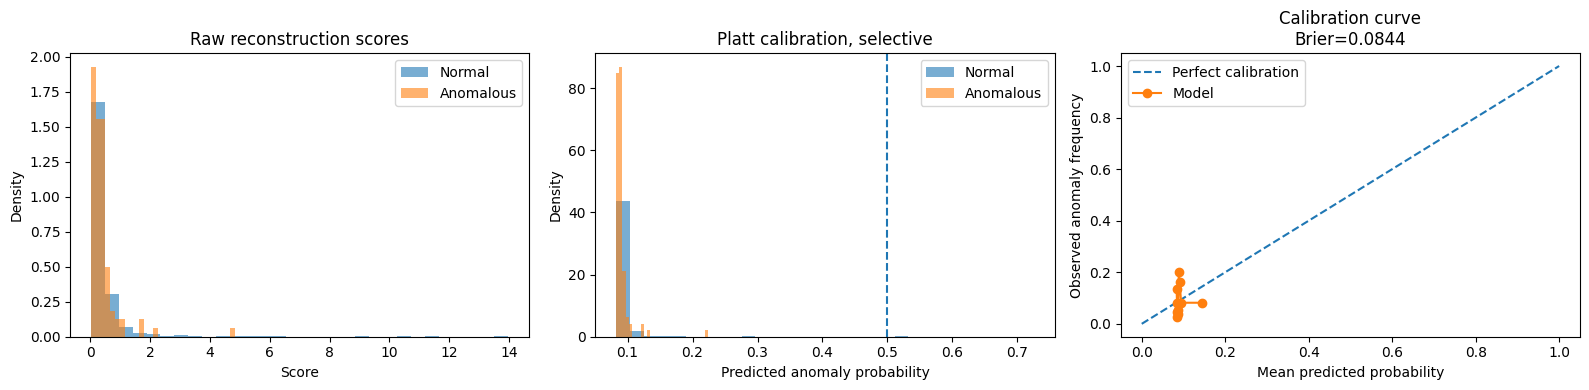

Isotonic calibration, selective


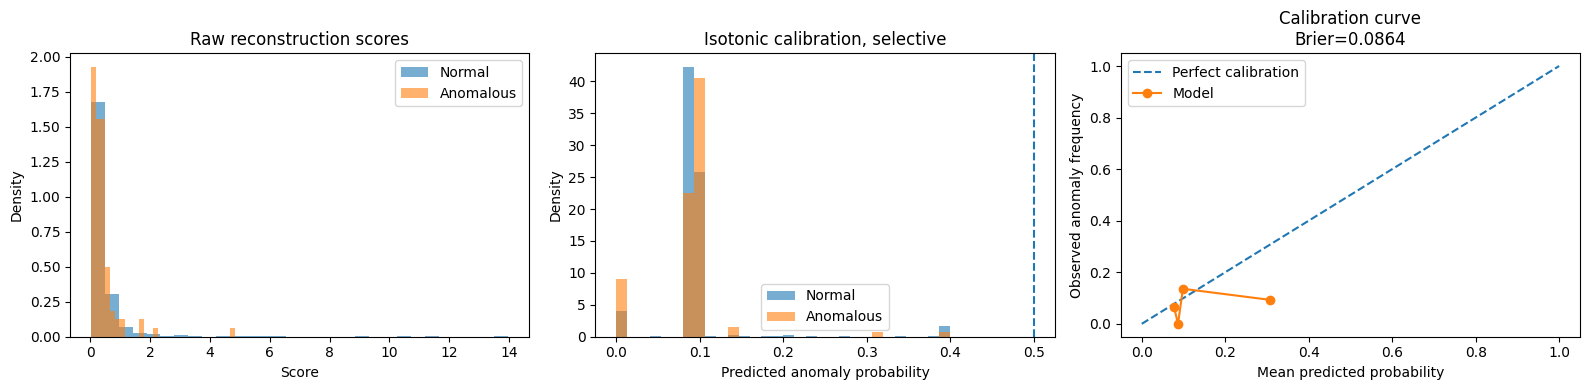

Weighted Scoring, selective


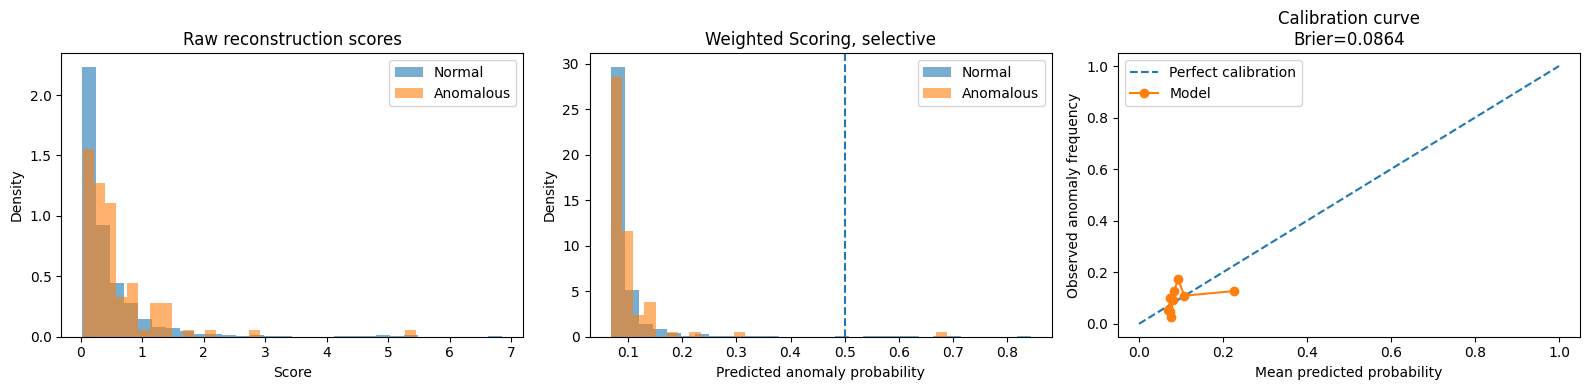

In [21]:
# Selective feature test
target_features = []
scores_cal_sel = get_selective_scores(model_unsup_p1, scaler_unsup, X_cal_unsup, feature_cols, )
scores_test_sel = get_selective_scores(model_unsup_p1, scaler_unsup, X_test, feature_cols)

# Weighted score test
weights = compute_weights(model_unsup_p1, scaler_unsup, X_cal_unsup, y_cal_unsup, feature_cols)
scores_cal_w = get_weighted_scores(model_unsup_p1, scaler_unsup, X_cal_unsup, feature_cols, weights)
scores_test_w = get_weighted_scores(model_unsup_p1, scaler_unsup, X_test, feature_cols, weights)


print("Platt calibration, selective")
test_probs = platt_calibrator(y_cal_unsup, scores_cal_sel, scores_test_sel)
res = codabench_metrics(y_test, test_probs, "AE unsupervised, Platt, selective")
results_p1.append(res)
plot_calibration_diagnostics(y_test, scores_test_sel, test_probs, "Platt calibration, selective")


print("Isotonic calibration, selective")
test_probs = iso_calibrator(y_cal_unsup, scores_cal_sel, scores_test_sel)
res = codabench_metrics(y_test, test_probs, "AE unsupervised, Iso, selective")
results_p1.append(res)
plot_calibration_diagnostics(y_test, scores_test_sel, test_probs, "Isotonic calibration, selective")


lr = LogisticRegression()
lr.fit(scores_cal_w.reshape(-1, 1), y_cal_unsup)
test_probs = lr.predict_proba(scores_test_w.reshape(-1, 1))[:, 1]
print("Weighted Scoring, selective")
res = codabench_metrics(y_test, test_probs, "AE unsupervised, Weighted, selective")
results_p1.append(res)
plot_calibration_diagnostics(y_test, scores_test_w, test_probs, "Weighted Scoring, selective")

Platt calibration, selective


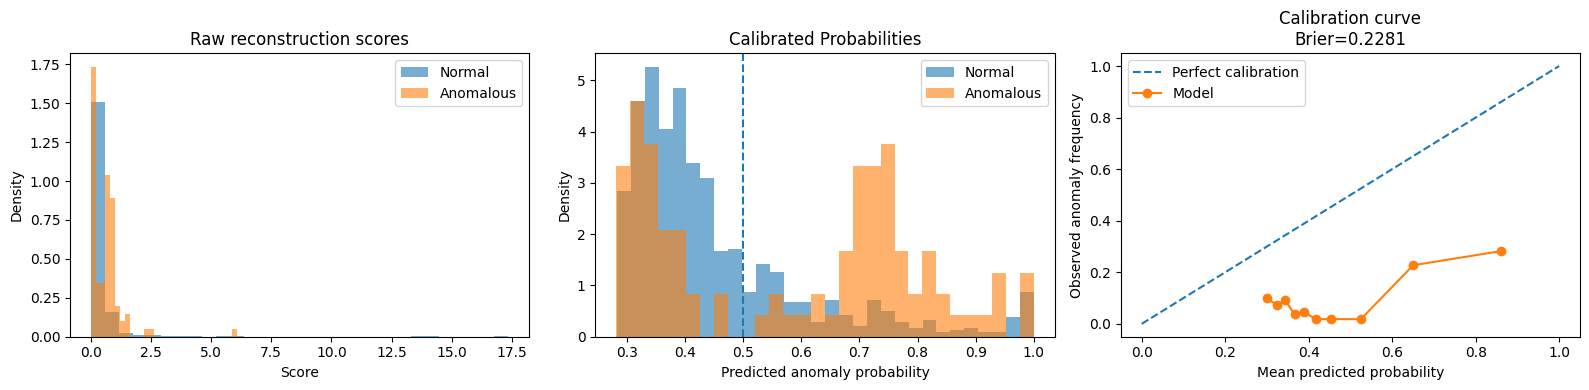

Isotonic calibration, selective


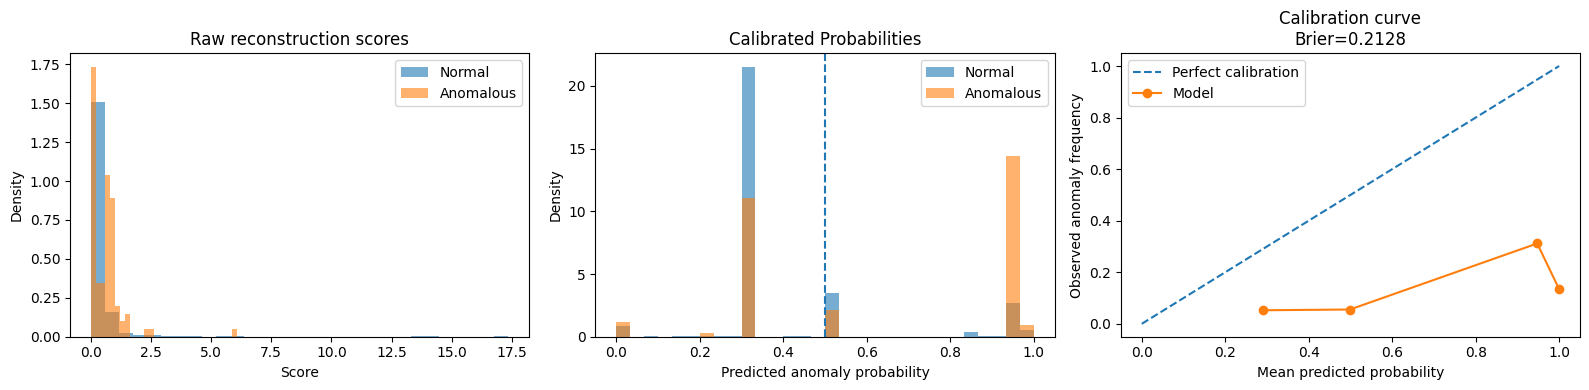

Weighted Scoring, selective


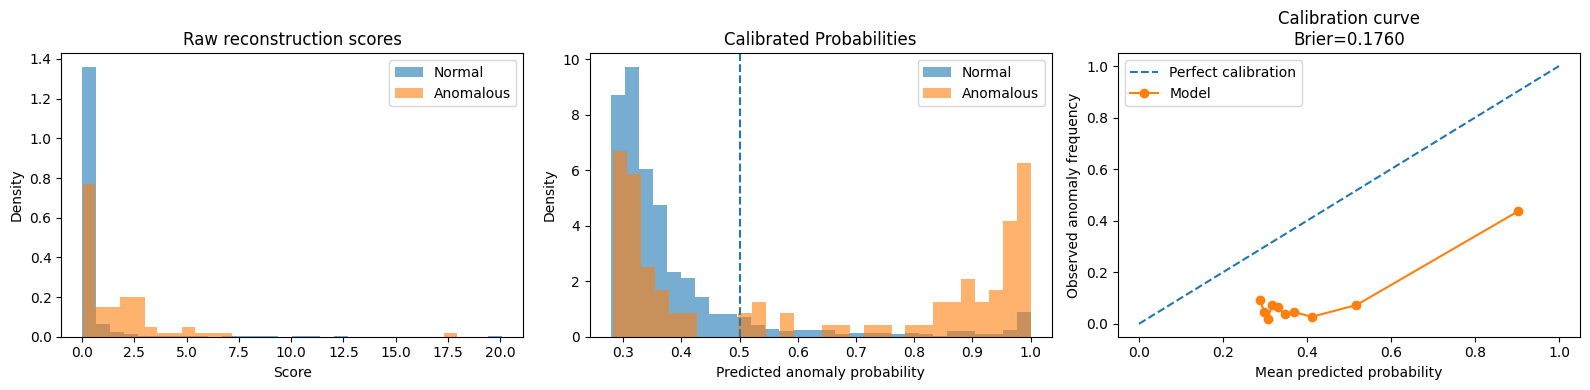

In [22]:
# Selective feature test
scores_cal_sel = get_selective_scores(model_semi_p1, scaler_semi, X_cal, feature_cols)
scores_test_sel = get_selective_scores(model_semi_p1, scaler_semi, X_test, feature_cols)

# Weighted score test
weights = compute_weights(model_semi_p1, scaler_semi, X_cal, y_cal, feature_cols)
scores_cal_w = get_weighted_scores(model_semi_p1, scaler_semi, X_cal, feature_cols, weights)
scores_test_w = get_weighted_scores(model_semi_p1, scaler_semi, X_test, feature_cols, weights)


print("Platt calibration, selective")
test_probs = platt_calibrator(y_cal, scores_cal_sel, scores_test_sel)
res = codabench_metrics(y_test, test_probs, "AE semi-supervised, Platt, selective")
results_p1.append(res)
plot_calibration_diagnostics(y_test, scores_test_sel, test_probs)


print("Isotonic calibration, selective")
test_probs = iso_calibrator(y_cal, scores_cal_sel, scores_test_sel)
res = codabench_metrics(y_test, test_probs, "AE semi-supervised, Iso, selective")
results_p1.append(res)
plot_calibration_diagnostics(y_test, scores_test_sel, test_probs)


lr = LogisticRegression()
lr.fit(scores_cal_w.reshape(-1, 1), y_cal)
test_probs = lr.predict_proba(scores_test_w.reshape(-1, 1))[:, 1]
print("Weighted Scoring, selective")
res = codabench_metrics(y_test, test_probs, "AE semi-supervised, Weighted, selective")
results_p1.append(res)
plot_calibration_diagnostics(y_test, scores_test_w, test_probs)

In [23]:
results_df = pd.DataFrame(results_p1)
results_df = results_df.sort_values(by="F1", ascending=False)

results_df

,model,AUC,Precision,Recall,F1,threshold
11,"AE semi-supervised, Weighted, selective",0.693900,0.329412,0.56,0.414815,0.5
10,"AE semi-supervised, Iso, selective",0.683795,0.193333,0.58,0.290000,0.5
9,"AE semi-supervised, Platt, selective",0.639080,0.190789,0.58,0.287129,0.5
4,"AE Semi-Supervised, Iso, full",0.613195,0.159236,0.50,0.241546,0.5
3,"AE Semi-Supervised, Platt, full",0.585740,0.154110,0.45,0.229592,0.5
0,"AE Unsupervised, Platt, full",0.531510,0.101788,0.74,0.178960,0.5
5,"AE Semi-Supervised, Mapping (base), full",0.585600,0.091846,0.98,0.167952,0.5
2,"AE Unsupervised, Mapping (base), full",0.468485,0.091328,0.99,0.167230,0.5
1,"AE Unsupervised, Iso, full",0.485960,0.060241,0.05,0.054645,0.5
8,"AE unsupervised, Weighted, selective",0.601190,0.076923,0.01,0.017699,0.5


## **Phase 2: Second Batch**

In [24]:
# SEMI-SUPERVISED: TRAIN, VAL - NORMAL USERS ONLY, CALIBRATION - BOTH NORMAL AND ANOMALOUS
from feature_pipeline import combine_labeled_data

# Split users by normal/anomalous
combined = combine_labeled_data("data/training_batch_with_labels.npz", "data/first_batch_with_labels.npz")
X, y = load_npz(combined)
y = y[["user", "label"]].drop_duplicates()
normal_users = y[y["label"] == 0].copy()
anomalous_users = y[y["label"] == 1].copy()
print(f"{len(normal_users)} normal users")
print(f"{len(anomalous_users)} anomalous users")

# Split NORMAL users into train, validation, calibration sets (80/10/10)
train_users, other_users = train_test_split(normal_users, test_size=0.2, random_state=RANDOM_SEED, shuffle=True)
val_users, cal_norm_users = train_test_split(other_users, test_size=0.5, random_state=RANDOM_SEED, shuffle=True)

# Add anomalous users to calibration set
cal_users = pd.concat([cal_norm_users, anomalous_users], ignore_index=True)
cal_users = cal_users.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

X_train, y_train, X_val, y_val, X_cal, y_cal = split_datasets(X, y, train_users, val_users, cal_users)

# Build features for train, val, test sets (global stats based on train data only)
item_stats = compute_item_stats(X_train)

# Training data
user_df = build_features(X_train, item_stats, TOTAL_ITEMS).merge(y_train, on="user")
feature_cols = get_feature_columns(user_df)
X_train = user_df[feature_cols].values
y_train = user_df["label"].values

# Validation data
val_df = build_features(X_val, item_stats, TOTAL_ITEMS).merge(y_val, on="user")
X_val = val_df[feature_cols].values
y_val = val_df["label"].values

# Calibration data
cal_df = build_features(X_cal, item_stats, TOTAL_ITEMS).merge(y_cal, on="user")
X_cal = cal_df[feature_cols].values
y_cal = cal_df["label"].values

# Test data
X_test, _ = load_npz("data/second_batch.npz")
test_df = build_features(X_test, item_stats, TOTAL_ITEMS)
X_test = test_df[feature_cols].values

Combined 2 files → data/combined_training.npz
  2200 users (200 anomalous, 2000 normal), 344839 interactions
2000 normal users
200 anomalous users

Train label counts:
label
0    1600
Name: count, dtype: int64

Val label counts:
label
0    200
Name: count, dtype: int64

Calibration label counts:
label
1    200
0    200
Name: count, dtype: int64


In [25]:
model_semi_p2, scaler_semi, tl_semi, vl_semi = train_autoencoder(
    X_train, X_val, 
    **AE_SMALL
)

weights = compute_weights(model_semi_p2, scaler_semi, X_cal, y_cal, feature_cols)
scores_cal_w = get_weighted_scores(model_semi_p2, scaler_semi, X_cal, feature_cols, weights)
scores_test_w = get_weighted_scores(model_semi_p2, scaler_semi, X_test, feature_cols, weights)

lr = LogisticRegression()
lr.fit(scores_cal_w.reshape(-1, 1), y_cal)
test_probs = lr.predict_proba(scores_test_w.reshape(-1, 1))[:, 1]
print("Weighted Scoring, selective")
save_submission(test_probs, "AE_P2_Weighted.npz")


TRAINING AUTOENCODER (dims=(8, 3), dropout=0.2, lr=0.0005)...
  Early stopping at epoch 200 (best val loss: 0.567018)
  Final train loss: 0.654440, best val loss: 0.567018
Weighted Scoring, selective
Saved to AE_P2_Weighted.npz
